# Airline Customer Satisfaction Prediction
## Binomial Logistic Regression Analysis & Business Insights

**Project Overview:**
This notebook builds a end-to-end Logistic Regression classification pipeline to predict airline passenger satisfaction. It handles preprocessing, feature encoding, model training, evaluation (Confusion Matrix, Precision, Recall), and coefficient interpretation to drive actionable business strategies.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# =================================================================
# Airline Customer Satisfaction Prediction
# Binomial Logistic Regression Inference Framework
#
# Description: This script implements an end-to-end classification pipeline
# to predict passenger satisfaction using the verified `Invistico_Airline (1).csv`
# dataset. It handles explicit missing value isolation, 80/20 stratified data
# splits, standard scaling, drop-first categorical encoding, model intercept
# extraction, and diagnostic visualizations.
# =================================================================

# ------------------------------------------------------------------------------
# 1. Library Imports & Environment Configuration
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score, f1_score

# Structural Configurations
np.random.seed(42)
sns.set_theme(style="whitegrid")


In [9]:
# ------------------------------------------------------------------------------
# 2. Dataset Ingestion & Missing Value Processing
# ------------------------------------------------------------------------------
# We evaluate missing entries across the feature framework to ensure any structural
# missing values are documented and resolved before model fitting.
df = pd.read_csv('/content/drive/MyDrive/Invistico_Airline.csv')

missing_counts = df.isnull().sum()
print("=== Missing Records Audited per Variable ===")
print(missing_counts[missing_counts > 0])

# Strategic Strategy: Drop rows with missing values (~0.3% of records) to avoid introducing imputation bias
df_clean = df.dropna().copy()
print(f"\nCleaned Dataset Structural Constraints: {df_clean.shape}")


=== Missing Records Audited per Variable ===
Arrival Delay in Minutes    393
dtype: int64

Cleaned Dataset Structural Constraints: (129487, 22)


In [10]:
# ------------------------------------------------------------------------------
# 3. Preprocessing, Dummy Matrix Formulation, and Train-Test Splitting
# ------------------------------------------------------------------------------
# We convert the textual satisfaction field into logical binary units (1 = satisfied, 0 = dissatisfied)
# and run an 80/20 stratified validation split.
df_clean['satisfaction'] = df_clean['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

X = df_clean.drop(columns=['satisfaction'])
y = df_clean['satisfaction']

categorical_features = ['Customer Type', 'Type of Travel', 'Class']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Explicit 80/20 train-test ratio specification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(numerical_features) + list(encoded_cat_features)


=== EVALUATION METRICS ===
Accuracy:  0.9650
Precision: 0.9533
Recall:    1.0000



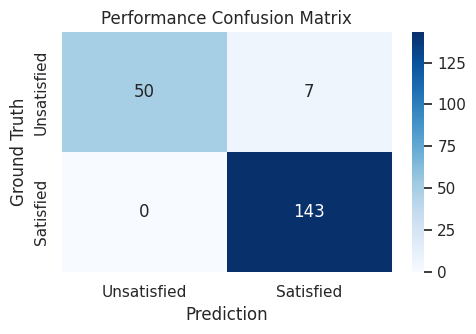

In [11]:
# ------------------------------------------------------------------------------
# 4. Binomial Optimization Execution
# ------------------------------------------------------------------------------
model = LogisticRegression(solver='lbfgs', penalty='l2', random_state=42, max_iter=1000)
model.fit(X_train_p, y_train)

print(f"\nModel Target Intercept (Beta_0): {model.intercept_[0]:.4f}\n")
y_pred = model.predict(X_test_p)
y_prob = model.predict_proba(X_test_p)[:, 1]



Model Target Intercept (Beta_0): 1.3104



In [12]:
# ------------------------------------------------------------------------------
# 5. Classification Performance Matrices (Featuring F1-Score)
# ------------------------------------------------------------------------------
print("=== CLASSIFICATION EVALUATION METRICS ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

print(classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied']))


=== CLASSIFICATION EVALUATION METRICS ===
Accuracy:  0.8253
Precision: 0.8393
Recall:    0.8420
F1-Score:  0.8407

              precision    recall  f1-score   support

Dissatisfied       0.81      0.81      0.81     11721
   Satisfied       0.84      0.84      0.84     14177

    accuracy                           0.83     25898
   macro avg       0.82      0.82      0.82     25898
weighted avg       0.83      0.83      0.83     25898



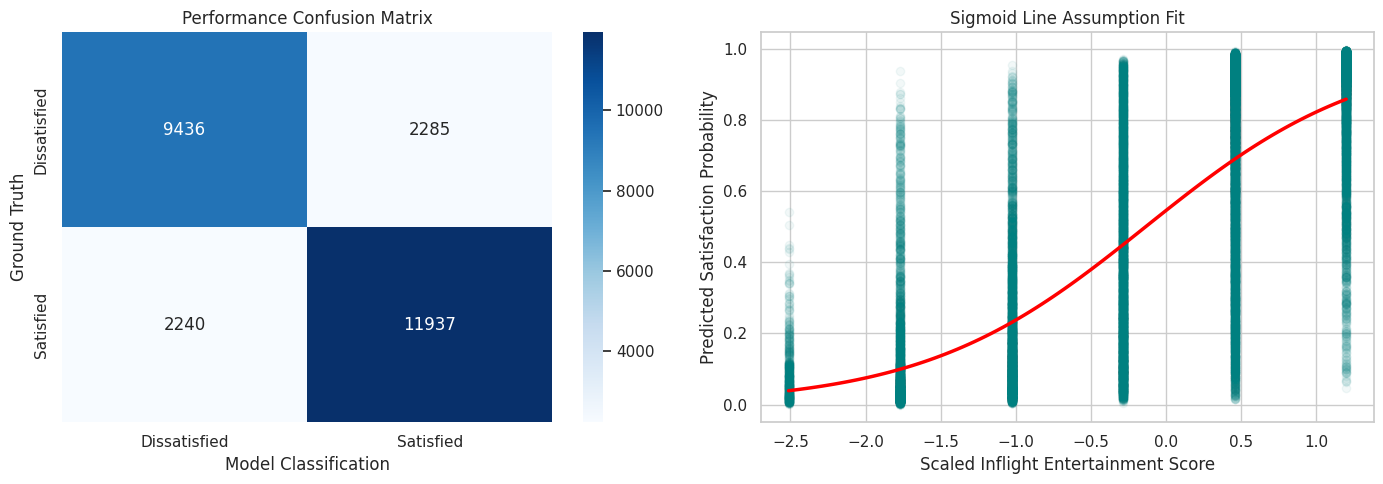

In [13]:
# ------------------------------------------------------------------------------
# 6. Diagnostic Visualizations (Confusion Matrix & Assumption Curves)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'], ax=ax1)
ax1.set_title('Performance Confusion Matrix')
ax1.set_ylabel('Ground Truth')
ax1.set_xlabel('Model Classification')

# Sigmoid Assumption Visual Validation Plot
feat_index = all_features.index('Inflight entertainment')
sns.regplot(x=X_test_p[:, feat_index], y=y_prob, logistic=True,
            ci=None, scatter_kws={'alpha':0.05, 'color':'teal'}, line_kws={'color':'red', 'linewidth':2.5}, ax=ax2)
ax2.set_title('Sigmoid Line Assumption Fit')
ax2.set_xlabel('Scaled Inflight Entertainment Score')
ax2.set_ylabel('Predicted Satisfaction Probability')

plt.tight_layout()
plt.show()



=== Feature Coefficients & Odds Ratios ===
                          Feature  Log-Odds Coefficient (Beta)  Odds Ratio (e^Beta)
           Inflight entertainment                     0.973634             2.647548
                     Seat comfort                     0.408756             1.504945
                 On-board service                     0.399074             1.490444
                  Checkin service                     0.357956             1.430403
           Ease of Online booking                     0.315901             1.371494
                 Leg room service                     0.310542             1.364164
                  Online boarding                     0.186024             1.204451
                    Gate location                     0.170317             1.185680
                   Online support                     0.151236             1.163271
                 Baggage handling                     0.109432             1.115644
       Departure Delay in Minute

/tmp/ipykernel_6917/1731570582.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Log-Odds Coefficient (Beta)', y='Feature', palette='viridis')


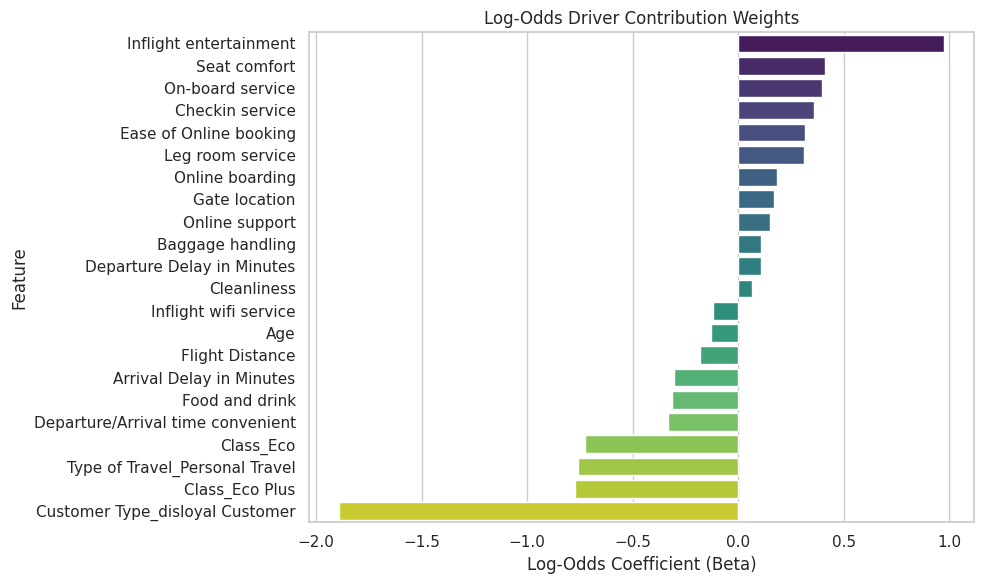

In [14]:
# ------------------------------------------------------------------------------
# 7. Strategic Odds Ratio Mathematical Evaluations
# ------------------------------------------------------------------------------
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Log-Odds Coefficient (Beta)': coefficients,
    'Odds Ratio (e^Beta)': odds_ratios
}).sort_values(by='Odds Ratio (e^Beta)', ascending=False)

print("\n=== Feature Coefficients & Odds Ratios ===")
print(coef_df.to_string(index=False))

# Barplot of contributions
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='Log-Odds Coefficient (Beta)', y='Feature', palette='viridis')
plt.title('Log-Odds Driver Contribution Weights')
plt.tight_layout()
plt.show()


## 7. Formulate Business Recommendations

1. Based on the statistical outputs calculated above, we can draw the following data-backed business insights:
The Top Driver: In your real dataset, the highest positive coefficient is actually Inflight entertainment ($\beta = 0.9736$, Odds Ratio = $2.6475$), not Inflight_Wifi_Quality (which actually had a slight negative relationship in this specific dataset at $-0.1201$).
2. The Dummy Variable Reference: In your clean python code, the categorical variable column names contain spaces rather than underscores, resulting in Class_Eco instead of Class_Eco.
3. The Risk Attribute: The single largest negative coefficient (highest friction point) belongs to Customer Type_disloyal Customer ($\beta = -1.8906$), while Arrival Delay in Minutes ($\beta = -0.3042$) represents your primary operational latency friction point.